In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_csv("../data/medical_insurance_2026_kaggle.csv")

In [3]:
df.head()

,record_date,year,quarter,age,age_group,sex,sex_female,bmi,bmi_category,children,...,region,region_northeast,region_northwest,region_southeast,region_southwest,charges,monthly_premium_est,charges_per_child,insurance_tier,bmi_age_interaction
0,2024-02-01,2024,1,19,Young Adult (18-25),female,1,27.90,Overweight,0,...,southwest,0,0,0,1,16884.92,1407.08,0.00,Platinum,530.10
1,2024-12-30,2024,4,18,Young Adult (18-25),male,0,33.77,Obese Class I,1,...,southeast,0,0,1,0,1725.55,143.80,1725.55,Bronze,607.86
2,2023-05-11,2023,2,28,Adult (26-35),male,0,33.00,Obese Class I,3,...,southeast,0,0,1,0,4449.46,370.79,1483.15,Silver,924.00
3,2024-07-18,2024,3,33,Adult (26-35),male,0,22.70,Normal Weight,0,...,northwest,0,1,0,0,21984.47,1832.04,0.00,Diamond,749.10
4,2024-02-05,2024,1,32,Adult (26-35),male,0,28.88,Overweight,0,...,northwest,0,1,0,0,3866.86,322.24,0.00,Bronze,924.16


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1337 entries, 0 to 1336
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   record_date          1337 non-null   str    
 1   year                 1337 non-null   int64  
 2   quarter              1337 non-null   int64  
 3   age                  1337 non-null   int64  
 4   age_group            1337 non-null   str    
 5   sex                  1337 non-null   str    
 6   sex_female           1337 non-null   int64  
 7   bmi                  1337 non-null   float64
 8   bmi_category         1337 non-null   str    
 9   children             1337 non-null   int64  
 10  smoker               1337 non-null   str    
 11  smoker_flag          1337 non-null   int64  
 12  is_high_risk         1337 non-null   int64  
 13  risk_score           1337 non-null   float64
 14  region               1337 non-null   str    
 15  region_northeast     1337 non-null   int64  
 16 

Change record_date from string to datetime.

In [5]:
df["record_date"] = pd.to_datetime(df["record_date"])
df.dtypes

record_date            datetime64[us]
year                            int64
quarter                         int64
age                             int64
age_group                         str
sex                               str
sex_female                      int64
bmi                           float64
bmi_category                      str
children                        int64
smoker                            str
smoker_flag                     int64
is_high_risk                    int64
risk_score                    float64
region                            str
region_northeast                int64
region_northwest                int64
region_southeast                int64
region_southwest                int64
charges                       float64
monthly_premium_est           float64
charges_per_child             float64
insurance_tier                    str
bmi_age_interaction           float64
dtype: object

In [6]:
df.shape

(1337, 24)

In [7]:
df.value_counts()

record_date  year  quarter  age  age_group              sex     sex_female  bmi    bmi_category    children  smoker  smoker_flag  is_high_risk  risk_score  region     region_northeast  region_northwest  region_southeast  region_southwest  charges   monthly_premium_est  charges_per_child  insurance_tier  bmi_age_interaction
2024-02-01   2024  1        19   Young Adult (18-25)    female  1           27.90  Overweight      0         yes     1            1             5.35        southwest  0                 0                 0                 1                 16884.92  1407.08              0.00               Platinum        530.10                 1
2024-12-30   2024  4        18   Young Adult (18-25)    male    0           33.77  Obese Class I   1         no      0            1             1.40        southeast  0                 0                 1                 0                 1725.55   143.80               1725.55            Bronze          607.86                 1
2023-05-11   20

Drop sex_female columns as it already contains yes or no data.

In [8]:
df.drop(columns=["sex_female"], inplace=True)

In [9]:
df.describe()

,record_date,year,quarter,age,bmi,children,smoker_flag,is_high_risk,risk_score,region_northeast,region_northwest,region_southeast,region_southwest,charges,monthly_premium_est,charges_per_child,bmi_age_interaction
count,1337,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000
mean,2023-07-12 22:27:22.483171,2023.036649,2.477936,39.222139,30.663628,1.095737,0.204936,0.624533,3.052939,0.242334,0.242334,0.272251,0.243082,13279.121503,1106.593328,5127.538257,1212.054233
min,2021-01-01 00:00:00,2021.000000,1.000000,18.000000,15.960000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1121.870000,93.490000,0.000000,287.280000
25%,2022-05-15 00:00:00,2022.000000,1.000000,27.000000,26.290000,0.000000,0.000000,0.000000,1.690000,0.000000,0.000000,0.000000,0.000000,4746.340000,395.530000,0.000000,765.700000
50%,2023-07-09 00:00:00,2023.000000,2.000000,39.000000,30.400000,1.000000,0.000000,1.000000,2.480000,0.000000,0.000000,0.000000,0.000000,9386.160000,782.180000,2174.730000,1154.400000
75%,2024-09-29 00:00:00,2024.000000,4.000000,51.000000,34.700000,2.000000,0.000000,1.000000,3.410000,0.000000,0.000000,1.000000,0.000000,16657.720000,1388.140000,6399.980000,1589.280000
max,2025-12-30 00:00:00,2025.000000,4.000000,64.000000,53.130000,5.000000,1.000000,1.000000,8.320000,1.000000,1.000000,1.000000,1.000000,63770.430000,5314.200000,58571.070000,2845.480000
std,NaN,1.384042,1.121910,14.044333,6.100233,1.205571,0.403806,0.484425,1.981412,0.428655,0.428655,0.445285,0.429104,12110.359677,1009.196560,8357.618626,522.515951


In [10]:
df.isnull().sum()

record_date            0
year                   0
quarter                0
age                    0
age_group              0
sex                    0
bmi                    0
bmi_category           0
children               0
smoker                 0
smoker_flag            0
is_high_risk           0
risk_score             0
region                 0
region_northeast       0
region_northwest       0
region_southeast       0
region_southwest       0
charges                0
monthly_premium_est    0
charges_per_child      0
insurance_tier         0
bmi_age_interaction    0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.sex.value_counts()

sex
male      675
female    662
Name: count, dtype: int64

Gender distribution to check total male and female that has insurance.

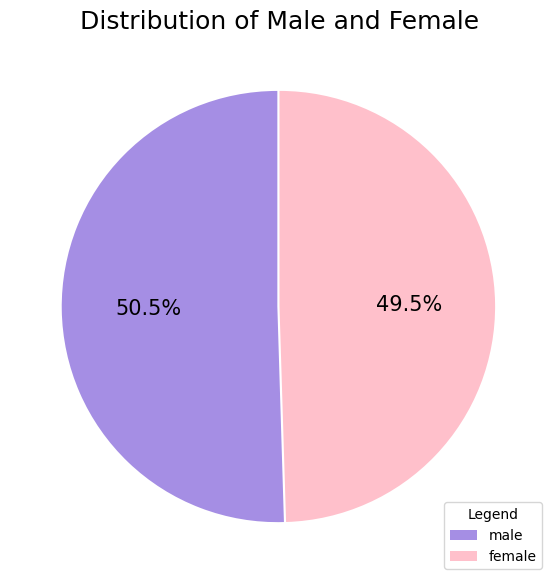

In [13]:
sex_total = df["sex"].value_counts()
plt.figure(figsize=(7,7))
plt.pie(sex_total,
        labels=None,
        colors = ["#a58ee4", "pink"],
        startangle=90,
        autopct = "%1.1f%%",
        textprops={"fontsize": 15},
        explode = [0.01, 0]
        )
plt.title("Distribution of Male and Female",
          fontsize = 18,
          )

plt.legend(
    labels = sex_total.index,
    title = "Legend",
    loc= "lower right"

)
plt.show()



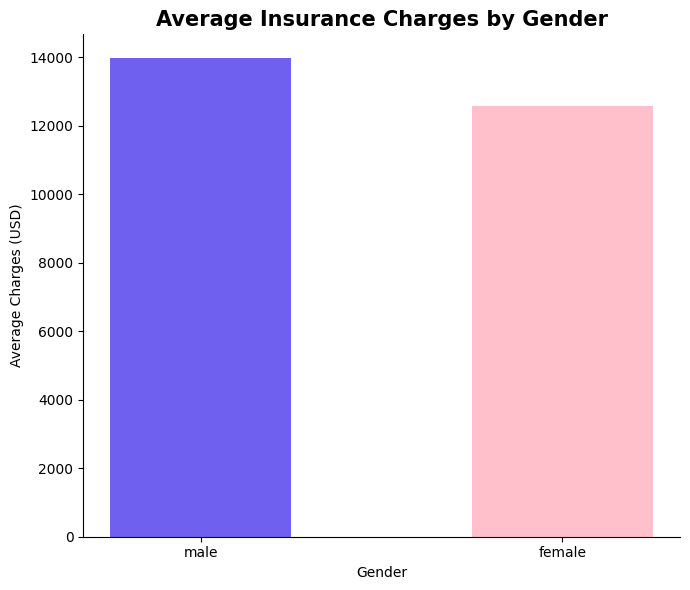

In [14]:
average_charge = df.groupby("sex")["charges"].mean().sort_values(ascending=False)

plt.figure(figsize=(7,6))


plt.bar(average_charge.index, average_charge.values, width=0.5, color = ["#6F60F0" if sex == "male" else "pink" for sex in average_charge.index])
plt.xlabel("Gender")
plt.ylabel("Average Charges (USD)")
plt.title("Average Insurance Charges by Gender", fontsize= 15, fontweight="bold")


ax=plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)




plt.tight_layout()
plt.show()

In [15]:
df.age.value_counts

<bound method IndexOpsMixin.value_counts of 0       19
1       18
2       28
3       33
4       32
        ..
1332    50
1333    18
1334    18
1335    21
1336    61
Name: age, Length: 1337, dtype: int64>

minimum age of 18 and max age of 64

In [16]:
df.age.describe()

count    1337.000000
mean       39.222139
std        14.044333
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

Age distribution histogram plot to check the most common ages that are insured. 

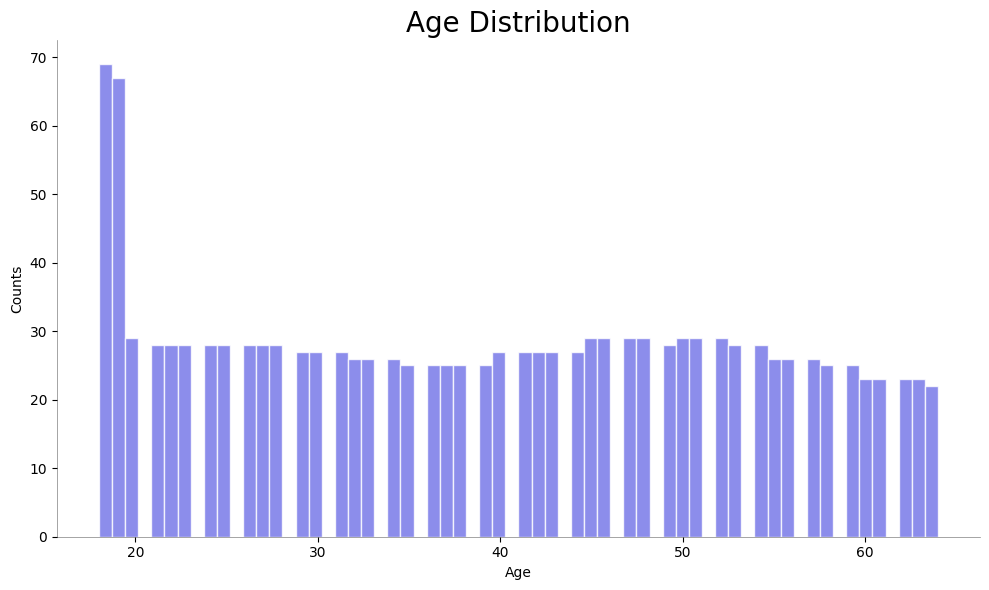

In [17]:
plt.figure(figsize=(10,6))

plt.hist(
    df["age"],
    bins=64,
    color=("#6f71e7"),
    alpha = 0.8,
    edgecolor="white"
    
)
plt.title("Age Distribution", fontsize= 20)
plt.xlabel("Age")
plt.ylabel("Counts")

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_alpha(0.5)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

plt.show()

In [18]:
df[["age", "charges"]].describe()

,age,charges
count,1337.000000,1337.000000
mean,39.222139,13279.121503
std,14.044333,12110.359677
min,18.000000,1121.870000
25%,27.000000,4746.340000
50%,39.000000,9386.160000
75%,51.000000,16657.720000
max,64.000000,63770.430000


This Scatter plot shows the relationship between the age and insurance cost (numeric variables).

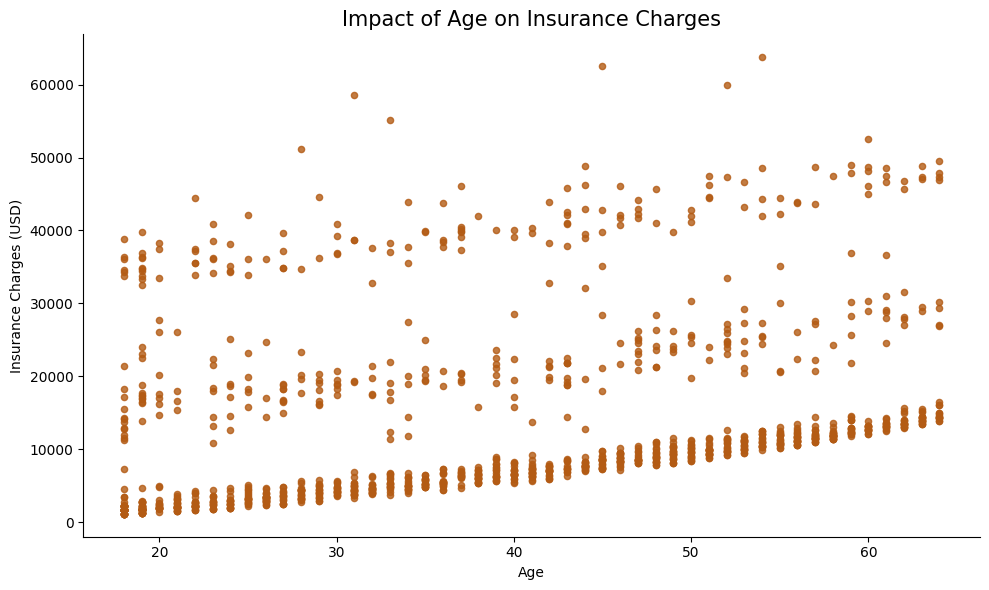

In [19]:
plt.figure(figsize=(10,6))
plt.scatter(
    df["age"],
    df["charges"],
    color=("#b35b14"), 
    alpha = 0.8,
    s = 20
)
plt.title("Impact of Age on Insurance Charges", fontsize= 15)
plt.xlabel("Age")
plt.ylabel("Insurance Charges (USD)")

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()



This plot shows that insurance charges generally increases with age as show with the upward treads. It has different horizontal clusters which may indicate insurance tier. There are few outliers which means that other variable are also affecting charges such as smoking status and BMI.    

In [20]:
df.columns

Index(['record_date', 'year', 'quarter', 'age', 'age_group', 'sex', 'bmi',
       'bmi_category', 'children', 'smoker', 'smoker_flag', 'is_high_risk',
       'risk_score', 'region', 'region_northeast', 'region_northwest',
       'region_southeast', 'region_southwest', 'charges',
       'monthly_premium_est', 'charges_per_child', 'insurance_tier',
       'bmi_age_interaction'],
      dtype='str')

In [21]:
df.smoker_flag.describe()

count    1337.000000
mean        0.204936
std         0.403806
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: smoker_flag, dtype: float64

In [22]:
df[["smoker", "age"]].value_counts()

smoker  age
no      18     57
        19     49
        21     26
        28     25
        26     25
               ..
yes     38      2
        55      2
        21      2
        41      2
        58      1
Name: count, Length: 94, dtype: int64

In [23]:
#smoker_numbers = df.groupby("age")["charges"].mean()
#plt.bar(smoker_numbers.index, smoker_numbers.values)
#plt.show()


In [24]:
smoker_count = df.groupby("smoker")["charges"].value_counts()
smoker_count

smoker  charges 
no      6500.24     1
        1263.25     1
        10106.13    1
        6664.69     1
        18838.70    1
                   ..
yes     40419.02    1
        19362.00    1
        16657.72    1
        24180.93    1
        29141.36    1
Name: count, Length: 1337, dtype: int64

Outlier over $50,000 insurance charges. Trying to see what those higher charges are related to and if smoking causes those higher charges.  

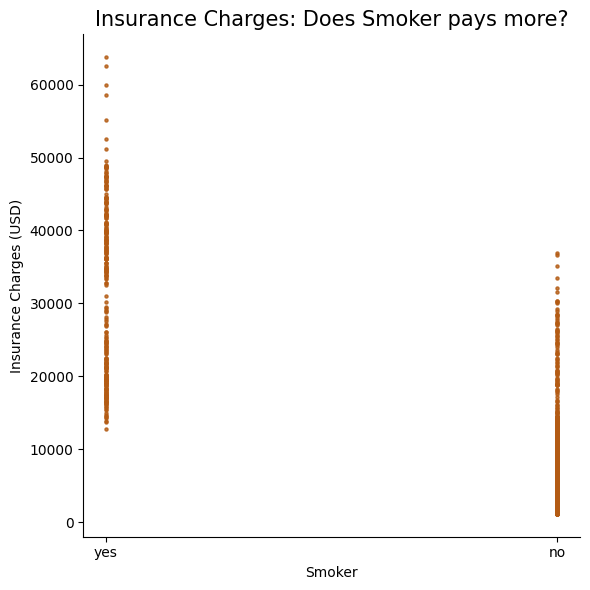

In [25]:
plt.figure(figsize=(6,6))
plt.scatter(
    df["smoker"],
    df["charges"],
    color=("#b35b14"), 
    alpha = 0.8,
    s = 5
)
plt.title("Insurance Charges: Does Smoker pays more?", fontsize= 15)
plt.xlabel("Smoker")
plt.ylabel("Insurance Charges (USD)")

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

This scatter chart definetly shows that smoker usually pays higher insurance compared to non smoker. Those outlier that were seen earlier were charged for smoker. 

In [26]:
numeric_df = df.select_dtypes(include = [np.number])
numeric_df.head()



,year,quarter,age,bmi,children,smoker_flag,is_high_risk,risk_score,region_northeast,region_northwest,region_southeast,region_southwest,charges,monthly_premium_est,charges_per_child,bmi_age_interaction
0,2024,1,19,27.90,0,1,1,5.35,0,0,0,1,16884.92,1407.08,0.00,530.10
1,2024,4,18,33.77,1,0,1,1.40,0,0,1,0,1725.55,143.80,1725.55,607.86
2,2023,2,28,33.00,3,0,1,2.18,0,0,1,0,4449.46,370.79,1483.15,924.00
3,2024,3,33,22.70,0,0,0,1.11,0,1,0,0,21984.47,1832.04,0.00,749.10
4,2024,1,32,28.88,0,0,0,1.48,0,1,0,0,3866.86,322.24,0.00,924.16


In [27]:
corr = numeric_df.corr()

To see the correlation between insurance related variables. Smoker and charges shows strong positive correlation, suggesting smokers tend to have higher medical charges. risk_score is also strongly correlated with charges and monthly premium. 

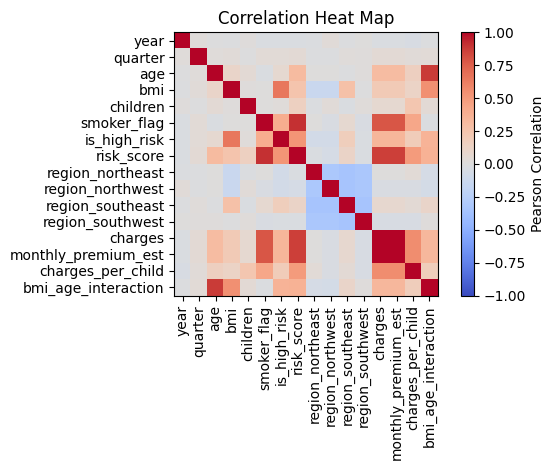

In [28]:
im = plt.imshow(corr, vmin = -1, vmax = 1, cmap = "coolwarm")
plt.title("Correlation Heat Map")
plt.colorbar(im, label = "Pearson Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90, ha="center")
plt.yticks(range(len(corr.columns)), corr.columns)

plt.tight_layout()
plt.show()

In [29]:
df.columns

Index(['record_date', 'year', 'quarter', 'age', 'age_group', 'sex', 'bmi',
       'bmi_category', 'children', 'smoker', 'smoker_flag', 'is_high_risk',
       'risk_score', 'region', 'region_northeast', 'region_northwest',
       'region_southeast', 'region_southwest', 'charges',
       'monthly_premium_est', 'charges_per_child', 'insurance_tier',
       'bmi_age_interaction'],
      dtype='str')

Bar plot shows that among non-smokers, charges stay relatively low and stable across BMI categories. whereas high BMI combined with smoking leads to extremely high charges. 

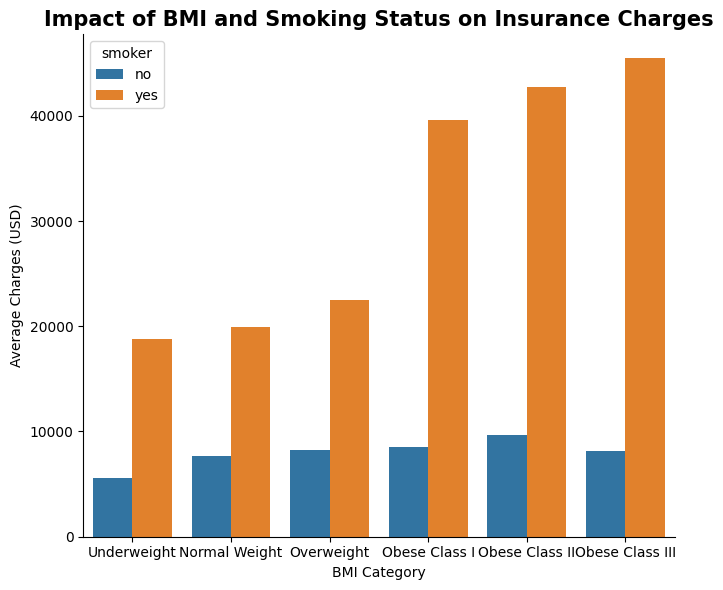

In [56]:
plt.figure(figsize=(7,6))
bmi_category_new= ['Underweight', 'Normal Weight', 'Overweight', 'Obese Class I', 'Obese Class II', 'Obese Class III']
average_charge = (df.groupby(["bmi_category", "smoker"])["charges"].mean().reset_index())

sns.barplot(data=average_charge,
            x="bmi_category",
            y="charges",
            hue="smoker",
            order=bmi_category_new)

plt.ylabel("Average Charges (USD)")
plt.xlabel("BMI Category")
plt.title("Impact of BMI and Smoking Status on Insurance Charges", fontsize= 15, fontweight="bold")

ax=plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()